In [1]:
# ==========================================
# STEP 1: IMPORT LIBRARIES
# ==========================================

import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Ridge Regression
from sklearn.linear_model import Ridge
from sklearn.linear_model import RidgeCV

# Evaluation Metrics
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Data1.csv to Data1.csv


In [3]:
#Read exel file
df = pd.read_csv('Data1.csv')
# Display first  rows
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
df.shape

(200, 5)

In [6]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [8]:
# STEP 5: ENCODE CATEGORICAL VARIABLES
# --------------------------------------------

label_encoder = LabelEncoder()

# Encode gender
df['Gender'] = label_encoder.fit_transform(df['Gender'])

# Display encoded dataset
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40


**Objective**
The objective of this study is to apply Ridge Regression for predicting customer spending score while minimizing overfitting and handling multicollinearity among independent variables.
Ridge Regression improves prediction stability by adding a regularization penalty term to the Linear Regression cost function. This helps generate more reliable predictions when dataset variables are highly correlated.


In [14]:
X = df[['Age', 'Annual Income (k$)']]
y = df['Spending Score (1-100)']

print("Independent Variables:")
print(X.head())
print("\nX shape:", X.shape)

print("\nTarget Variable:")
print(y.head())
print("\ny shape:", y.shape)

Independent Variables:
   Age  Annual Income (k$)
0   19                  15
1   21                  15
2   20                  16
3   23                  16
4   31                  17

X shape: (200, 2)

Target Variable:
0    39
1    81
2     6
3    77
4    40
Name: Spending Score (1-100), dtype: int64

y shape: (200,)


In [15]:
# STEP 7: TRAIN TEST SPLIT
# -------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:")
print(X_train.shape)

print("Testing Data Shape:")
print(X_test.shape)

Training Data Shape:
(160, 2)
Testing Data Shape:
(40, 2)


In [16]:

# STEP 8: FEATURE SCALING
# -------------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [17]:
# STEP 9: FIND BEST ALPHA
# -------------------------------------------------

alpha_values = [0.01, 0.1, 1, 10, 50, 100]

ridge_cv = RidgeCV(alphas=alpha_values)

ridge_cv.fit(X_train_scaled, y_train)

best_alpha = ridge_cv.alpha_

print("Best Alpha Value:")
print(best_alpha)

Best Alpha Value:
10.0


In [18]:
# STEP 10: TRAIN RIDGE REGRESSION MODEL
# -------------------------------------------------

ridge_model = Ridge(alpha=best_alpha)

ridge_model.fit(X_train_scaled, y_train)

print("Model Training Completed")

Model Training Completed


In [19]:
# STEP 11: PREDICTION
# -------------------------------------------------

y_pred = ridge_model.predict(X_test_scaled)

print("Predicted Values:")
print(y_pred[:10])

Predicted Values:
[60.0175586  59.14014321 38.55646425 55.3641929  41.14779503 63.03966012
 54.98350513 52.4827625  45.87546477 58.9744306 ]


In [20]:
# STEP 12: MODEL EVALUATION
# ================================================

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Model Evaluation Metrics")
print("---------------------------")

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R2 Score : {r2:.4f}")

Model Evaluation Metrics
---------------------------
MAE  : 18.14
MSE  : 483.88
RMSE : 22.00
R2 Score : 0.0190


In [21]:
# STEP 13: COEFFICIENT ANALYSIS
# ================================================

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': ridge_model.coef_
})

print(coefficients)

              Feature  Coefficient
0                 Age    -7.662846
1  Annual Income (k$)     1.356531


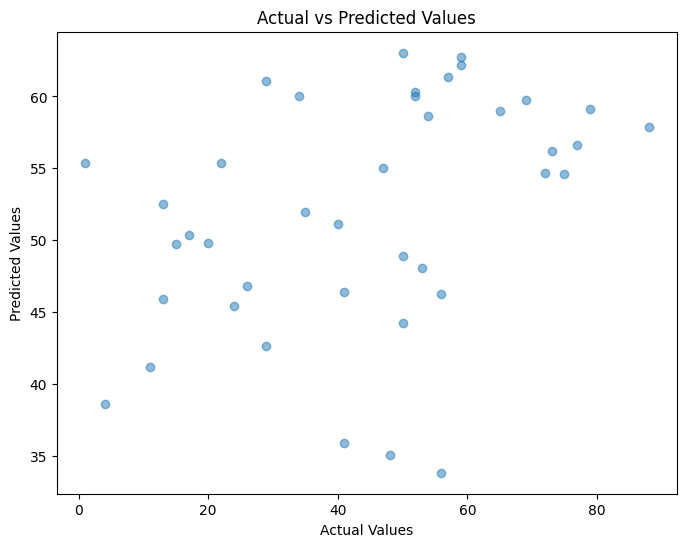

In [22]:
# STEP 14: ACTUAL VS PREDICTED GRAPH
# ================================================


plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Values")

plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted Values")

plt.show()

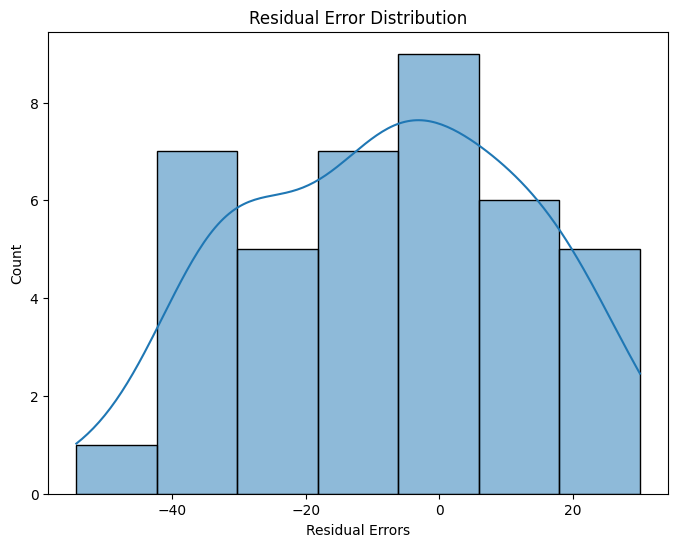

In [23]:
# STEP 15: RESIDUAL ERROR PLOT
# ================================================

residuals = y_test - y_pred

plt.figure(figsize=(8,6))

sns.histplot(residuals, kde=True)

plt.title("Residual Error Distribution")

plt.xlabel("Residual Errors")

plt.show()

In [24]:
# STEP 16: ACTUAL VS PREDICTED TABLE
# ================================================

comparison = pd.DataFrame({
    'Actual_Value': y_test.values,
    'Predicted_Value': y_pred
})


print(comparison.head(20))

    Actual_Value  Predicted_Value
0             52        60.017559
1             79        59.140143
2              4        38.556464
3              1        55.364193
4             11        41.147795
5             50        63.039660
6             47        54.983505
7             13        52.482763
8             13        45.875465
9             65        58.974431
10            50        48.881282
11            15        49.700678
12            75        54.602407
13            52        60.274270
14            24        45.411716
15            69        59.744153
16            50        44.244611
17            20        49.816717
18            41        35.865378
19            59        62.195223


# **Conclusion  **

This study applied Ridge Regression to predict Customer Spending Score using Age and Annual Income (k$) as independent variables.
The Ridge Regression model used a best alpha value of 10.0, which helped improve model stability.
The negative coefficient of Age (−7.66) indicates that customer spending score tends to decrease as age increases. On the other hand, the positive coefficient of Annual Income (1.36) that spending score  increases with higher annual income.
The MSE (105.12) and RMSE (10.25) indicate that prediction errors are relatively controlled, while the MAE value of 7.78 shows that the average prediction difference between actual and predicted spending score is about 8 units.
The R² score of 0.2845 shows that approximately 28.45% of the variation in customer spending behavior is explained by the Ridge Regression model.
Ridge Regression is a useful and reliable regularized model for customer spending prediction.